In [1]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# square root transformed expression
adata = sc.read_h5ad("discrete_cancer_stages_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'discrete_cancer_stage_colors', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [4]:
adata.X

array([[ 0. ,  0. ,  0. , ...,  0. ,  0. ,  7. ],
       [ 0. ,  0. ,  0. , ...,  0. ,  0. ,  3.5],
       [ 0. ,  0. ,  1. , ...,  0. ,  0. ,  4. ],
       ...,
       [ 0. ,  0. ,  0. , ...,  0. ,  0. ,  0.5],
       [ 0. ,  4. ,  0. , ...,  0. ,  0. , 11. ],
       [ 0. ,  0. ,  0. , ...,  0. ,  0. , 16. ]])

In [5]:
adata.layers['scvi_normalized']

array([[ 1.3660967 ,  1.5102433 ,  0.84264374, ...,  0.13126898,
         0.14069788, 64.436554  ],
       [ 1.0688094 ,  1.1575099 ,  0.64938474, ...,  0.10362872,
         0.1495432 , 75.53627   ],
       [ 1.3362994 ,  1.576865  ,  0.7316775 , ...,  0.13519967,
         0.1357406 , 71.79623   ],
       ...,
       [ 1.542854  ,  4.503489  ,  0.64815706, ...,  0.13795677,
         0.2050788 , 48.485855  ],
       [ 0.85531384,  7.3508344 ,  0.5020641 , ...,  0.1165168 ,
         0.18252064, 60.115337  ],
       [ 0.98095864,  4.400981  ,  0.55424696, ...,  0.10603125,
         0.2386962 , 87.08725   ]], dtype=float32)

In [6]:
# Sum each row
row_sums = np.sum(adata.layers['scvi_normalized'], axis=1)

# Print the result
print("Row sums:", row_sums)

Row sums: [100000.     99999.99  100000.01  ... 100000.     99999.984 100000.   ]


In [8]:
# # Normalize total counts per cell to a target sum (e.g., 10,000)
# sc.pp.normalize_total(adata, target_sum=1e4, layer='scvi_normalized')
# adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'discrete_cancer_stage_colors', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [10]:
adata.layers['scvi_log'] = adata.layers['scvi_normalized'].copy()
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'discrete_cancer_stage_colors', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized', 'scvi_log'
    obsp: 'connectivities', 'distances'

In [11]:
sc.pp.log1p(adata, layer='scvi_log')
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'discrete_cancer_stage_colors', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized', 'scvi_log'
    obsp: 'connectivities', 'distances'

In [12]:
adata.layers['scvi_log']

array([[0.12804987, 0.14065227, 0.08090176, ..., 0.01304149, 0.01397173,
        2.0073621 ],
       [0.1015461 , 0.10952772, 0.06291703, ..., 0.01030955, 0.01484361,
        2.1463556 ],
       [0.12542482, 0.14642361, 0.07061478, ..., 0.01342939, 0.01348276,
        2.101646  ],
       ...,
       [0.14348145, 0.37180415, 0.06280174, ..., 0.01370138, 0.02030042,
        1.7661998 ],
       [0.08206964, 0.55105555, 0.04898673, ..., 0.01158432, 0.0180875 ,
        1.9475566 ],
       [0.09357765, 0.36471125, 0.05394324, ..., 0.01054731, 0.0235892 ,
        2.273025  ]], dtype=float32)

In [13]:
adata.layers['scvi_scale'] = adata.layers['scvi_log'].copy()
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'discrete_cancer_stage_colors', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized', 'scvi_log', 'scvi_scale'
    obsp: 'connectivities', 'distances'

In [14]:
sc.pp.scale(adata, layer='scvi_scale')
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'discrete_cancer_stage'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'INSS_stage_colors', '_scvi_manager_uuid', '_scvi_uuid', 'discrete_cancer_stage_colors', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_sizes', 'neighbors', 'paga', 'sample_ID_colors', 'scrublet', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    layers: 'scvi_normalized', 'scvi_log', 'scvi_scale'
    obsp: 'connectivities', 'distances'

In [15]:
adata.layers['scvi_scale']

array([[-0.46020573, -1.181261  ,  0.6703537 , ..., -0.48453858,
         0.35390112,  0.5257946 ],
       [-0.73325384, -1.4258136 , -0.09961344, ..., -0.618265  ,
         0.45353538,  0.6564509 ],
       [-0.4872496 , -1.1359143 ,  0.2299445 , ..., -0.46555126,
         0.29802382,  0.61442304],
       ...,
       [-0.3012259 ,  0.6349517 , -0.10454928, ..., -0.45223722,
         1.0771141 ,  0.2990978 ],
       [-0.933905  ,  2.0433705 , -0.696001  , ..., -0.55586565,
         0.82423145,  0.46957636],
       [-0.8153467 ,  0.57922125, -0.48380163, ..., -0.6066268 ,
         1.452939  ,  0.7755224 ]], dtype=float32)

In [16]:
adata.write("discrete_cancer_stages.h5ad")

for 4S

In [17]:
# data_4S = pd.read_csv("/hdd/edward/the-project/results/4S_metacell.csv", index_col=0)
data_4S = adata[adata.obs.discrete_cancer_stage == "4S"]
data_4S = pd.DataFrame(data_4S.layers['scvi_scale'], index=data_4S.obs_names, columns=data_4S.var_names)
data_4S

Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Cell_barcode,,,,,,,,,,,,,,,,,,,,,
T44_AACACGTAGCGCTCCA.1,-0.566020,-0.659921,-0.111245,-0.714487,-0.051717,-0.906759,-1.059761,-0.821807,-0.473062,-0.536190,...,-0.848186,0.236826,-0.350619,-0.787570,-0.751901,0.881596,-0.633517,-0.723788,-0.121853,0.319366
T44_AACCATGGTCGATTGT.1,-0.599667,-0.618331,-0.380764,-0.792199,-0.004599,-1.061051,-1.076801,-0.859810,-0.677982,-0.761327,...,-1.162810,0.097657,-0.422891,-0.689551,-0.735922,0.708640,-0.744154,-0.776037,-0.188839,0.352049
T44_AACCGCGCAGTCGTGC.1,-0.296309,-0.698976,-0.418891,-0.841160,0.366467,-0.698946,-1.247636,-1.267085,0.460022,0.116103,...,-0.446276,0.487318,0.176374,-0.456864,-0.774135,1.772150,-0.585162,-0.673542,-0.026278,0.594310
T44_AACTCAGGTGCGGTAA.1,-0.052929,-0.829871,0.311859,-0.880965,0.776881,-0.809471,-0.877136,-1.036838,0.411110,0.610464,...,-0.402993,1.410510,0.145749,-0.371682,-0.441367,1.885829,-0.704457,-0.623968,0.313209,0.417224
T44_AACTGGTGTGTTGGGA.1,-0.627147,-1.094376,-0.109535,-0.917280,0.349474,-0.648861,-0.993838,-1.291977,0.686675,0.686533,...,-0.764699,1.058899,0.044528,-0.600711,-0.446347,1.711480,-0.735885,-0.630085,0.176974,0.717627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T40_TTTATGCTCTGCTGTC.1,-0.259273,1.181748,0.120281,0.771810,2.946945,-0.495856,-0.952468,-0.700129,-0.831549,-0.862551,...,-0.378859,-0.036009,0.896294,0.920964,-0.464052,0.474532,-0.230441,-0.621560,0.950187,0.154746
T40_TTTCCTCAGATGCCAG.1,-0.456098,1.424116,0.157379,-0.545544,4.427744,-0.092387,-0.474267,-0.542136,-0.304453,-0.320981,...,-0.239545,0.182886,1.507565,1.692426,-0.220516,0.809197,-0.158411,-0.466678,1.334405,0.691968
T40_TTTGCGCAGCTACCGC.1,-0.588592,2.221515,0.644328,-0.086314,4.489783,-0.292180,-0.614125,-0.092101,-0.701902,-0.219450,...,-0.188471,0.203911,1.240593,2.044065,-0.123627,0.604095,0.114100,-0.417432,1.169968,0.692326


In [18]:
pcc_4S = data_4S.corr()  # calculate the pairwise PCC value for each gene
pcc_4S

Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


In [19]:
# take a look what values should be set as thresholds
sum = 0
for colname in pcc_4S:
    for value in pcc_4S[colname]:
        if value > 0.5:
            sum += 1
print(sum/(pcc_4S.shape[0]**2))

0.09908158408153221


In [20]:
pcc_4S.to_csv("pcc_4S.csv")

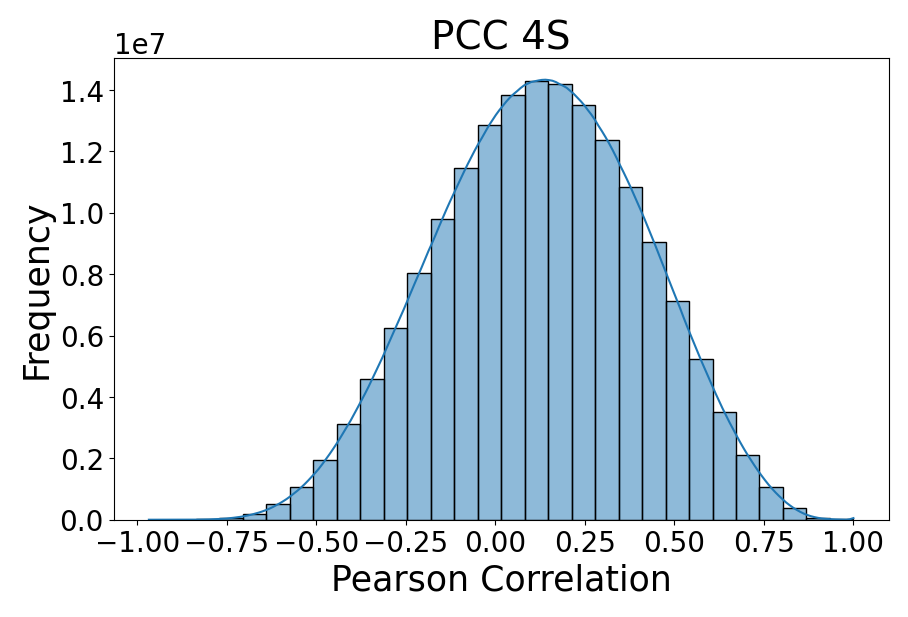

In [7]:
# Set font sizes using rcParams
plt.rcParams.update({
    'axes.titlesize': 28,
    'axes.labelsize': 25,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    "savefig.bbox": "tight"
})
# Melt the DataFrame to long format
df_melted = pcc_4S.melt()

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_melted['value'], bins=30, kde=True)
plt.title('PCC 4S')
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')

# Save the plot to a file
plt.savefig('./figures/pcc_4S.svg')
plt.show()

for I

In [22]:
# data_I = pd.read_csv("/hdd/edward/the-project/results/I_metacell.csv", index_col=0)
data_I = adata[adata.obs.discrete_cancer_stage == "I"]
data_I = pd.DataFrame(data_I.layers['scvi_scale'], index=data_I.obs_names, columns=data_I.var_names)
pcc_I = data_I.corr()  # calculate the pairwise PCC value for each gene
pcc_I.to_csv("pcc_I.csv")
pcc_I

Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.107186,0.003285,0.056567,0.317440,-0.184316,0.232333,0.099596,0.456284,0.262566,...,0.106963,0.174599,0.406201,0.212918,0.311296,0.217858,-0.044665,-0.353127,0.266048,-0.570060
DPM1,0.107186,1.000000,0.146014,0.668884,0.192856,-0.057535,0.183870,0.307373,0.125525,-0.467344,...,0.373399,-0.145764,0.375997,0.157474,0.359392,0.106671,-0.121857,-0.158947,0.336275,-0.276111
SCYL3,0.003285,0.146014,1.000000,0.301869,0.060579,0.239397,0.383222,0.271843,-0.092319,0.110659,...,0.334772,0.391966,-0.004672,-0.089531,0.586056,-0.120515,0.157024,0.482084,0.050174,-0.161069
C1orf112,0.056567,0.668884,0.301869,1.000000,0.119165,0.079607,0.208753,0.467044,-0.127322,-0.500644,...,0.457160,-0.127950,0.186204,0.126519,0.305876,-0.187052,0.017256,0.097902,0.069377,-0.371049
FGR,0.317440,0.192856,0.060579,0.119165,1.000000,-0.393483,0.166816,0.120979,0.398055,0.233847,...,0.366609,0.478241,0.721978,0.716994,0.522844,0.349946,-0.221204,-0.165732,0.535570,-0.199934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,0.217858,0.106671,-0.120515,-0.187052,0.349946,-0.497622,-0.261921,-0.372023,0.641458,0.478874,...,-0.032025,0.329933,0.388886,-0.044108,0.191549,1.000000,-0.691101,-0.604141,0.744366,-0.058452
CYB561D2,-0.044665,-0.121857,0.157024,0.017256,-0.221204,0.655300,0.315638,0.286086,-0.281936,-0.098861,...,0.108694,-0.023297,-0.127174,0.038020,-0.084974,-0.691101,1.000000,0.545011,-0.648629,0.096816
CCDC7,-0.353127,-0.158947,0.482084,0.097902,-0.165732,0.596642,0.267250,0.376546,-0.450070,-0.070536,...,0.318949,0.213623,-0.172701,0.019423,0.122841,-0.604141,0.545011,1.000000,-0.482713,0.269748


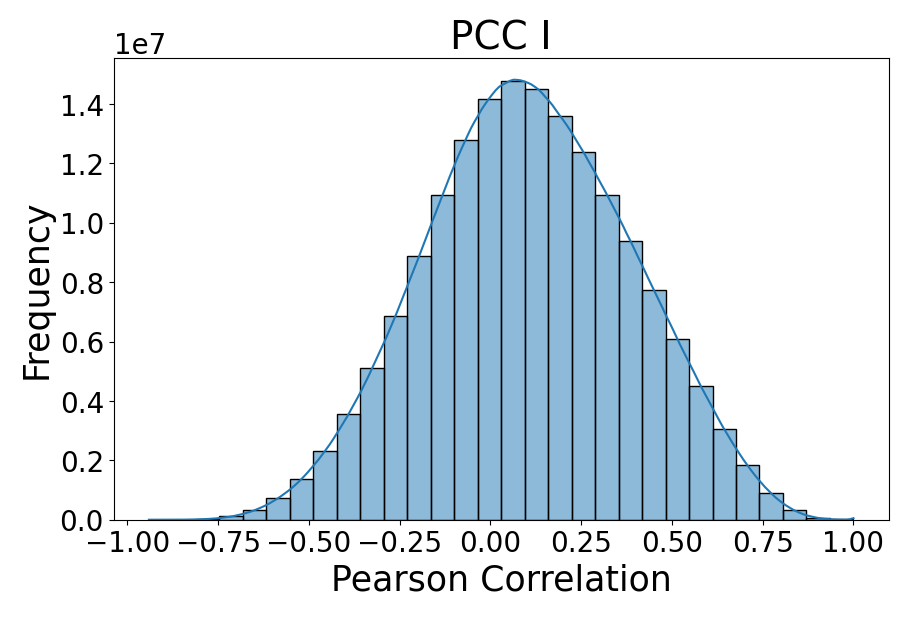

In [9]:
# Melt the DataFrame to long format
df_melted = pcc_I.melt()

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_melted['value'], bins=30, kde=True)
plt.title('PCC I')
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')

# Save the plot to a file
plt.savefig('./figures/pcc_I.svg')
plt.show()

for III

In [24]:
# data_III = pd.read_csv("/hdd/edward/the-project/results/III_metacell.csv", index_col=0)
data_III = adata[adata.obs.discrete_cancer_stage == "III"]
data_III = pd.DataFrame(data_III.layers['scvi_scale'], index=data_III.obs_names, columns=data_III.var_names)
pcc_III = data_III.corr()  # calculate the pairwise PCC value for each gene
pcc_III.to_csv("pcc_III.csv")
pcc_III

Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,-0.146118,-0.407583,-0.153526,-0.128608,0.127853,0.170577,0.179281,0.596301,0.527090,...,0.270543,-0.146169,-0.156280,-0.022540,-0.013927,0.039416,0.311863,-0.449043,-0.395498,-0.520577
DPM1,-0.146118,1.000000,0.317977,0.610711,0.427256,-0.194839,0.039539,0.192675,0.004157,-0.288117,...,0.001478,-0.142230,0.326853,0.253307,0.290853,0.480429,0.041889,0.019899,0.435636,0.182522
SCYL3,-0.407583,0.317977,1.000000,0.335949,0.449209,0.023153,0.219978,0.214271,-0.151263,-0.199445,...,0.170213,0.378069,0.253586,0.287354,0.603012,0.101602,0.140263,0.678668,0.576123,0.276615
C1orf112,-0.153526,0.610711,0.335949,1.000000,0.306138,-0.128630,0.218876,0.395229,-0.021705,-0.227944,...,0.257641,-0.203111,0.189014,0.111348,0.206499,-0.006630,0.114574,0.053996,0.165777,0.023030
FGR,-0.128608,0.427256,0.449209,0.306138,1.000000,-0.033375,0.210446,0.317264,0.169876,0.020681,...,0.295226,0.396413,0.580248,0.708960,0.467678,0.381224,0.024296,0.402929,0.456770,0.294027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,0.039416,0.480429,0.101602,-0.006630,0.381224,-0.232622,-0.145150,0.025157,0.215582,0.129807,...,0.018791,0.071592,0.269090,0.148870,0.290832,1.000000,-0.283737,-0.015301,0.389400,0.172422
CYB561D2,0.311863,0.041889,0.140263,0.114574,0.024296,0.477566,0.364526,0.158981,0.136874,-0.038632,...,0.044649,0.250989,0.224313,0.189946,-0.037724,-0.283737,1.000000,0.142270,-0.207228,-0.060973
CCDC7,-0.449043,0.019899,0.678668,0.053996,0.402929,0.184182,0.262453,0.199289,-0.291728,-0.289646,...,0.162170,0.623884,0.419176,0.389943,0.326559,-0.015301,0.142270,1.000000,0.390263,0.421783


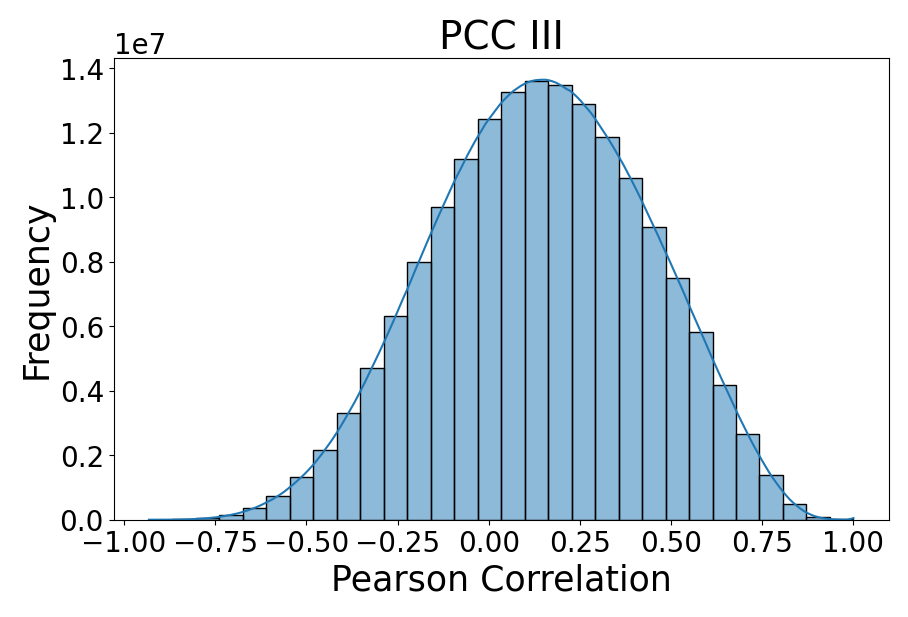

In [10]:
# Melt the DataFrame to long format
df_melted = pcc_III.melt()

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_melted['value'], bins=30, kde=True)
plt.title('PCC III')
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')

# Save the plot to a file
plt.savefig('./figures/pcc_III.svg')
plt.show()

for IV

In [26]:
# data_IV = pd.read_csv("/hdd/edward/the-project/results/IV_metacell.csv", index_col=0)
data_IV = adata[adata.obs.discrete_cancer_stage == "IV"]
data_IV = pd.DataFrame(data_IV.layers['scvi_scale'], index=data_IV.obs_names, columns=data_IV.var_names)
pcc_IV = data_IV.corr()  # calculate the pairwise PCC value for each gene
pcc_IV.to_csv("pcc_IV.csv")
pcc_IV

Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.360771,0.308318,0.144412,-0.052427,0.073496,0.101674,0.281178,-0.025117,0.130521,...,-0.029552,-0.496186,0.026474,-0.136884,0.064846,-0.172473,0.212637,-0.404198,0.031361,-0.752201
DPM1,0.360771,1.000000,0.280470,0.353892,0.310704,0.115831,0.324405,0.340075,0.212385,-0.221568,...,0.329319,-0.043695,0.549480,0.051601,0.276221,0.190146,0.111768,-0.113002,0.229664,-0.199733
SCYL3,0.308318,0.280470,1.000000,0.408128,0.257744,0.476485,0.585565,0.606047,0.233244,0.382066,...,0.581334,0.351388,0.175312,0.173734,0.573304,-0.204652,0.603437,0.128362,-0.194951,-0.242491
C1orf112,0.144412,0.353892,0.408128,1.000000,0.184409,0.444725,0.506966,0.676249,0.149200,-0.042115,...,0.587133,-0.001174,0.124835,0.218853,0.443362,-0.474906,0.567591,0.023140,-0.358126,-0.240937
FGR,-0.052427,0.310704,0.257744,0.184409,1.000000,-0.043782,0.247892,0.235439,0.191635,0.122157,...,0.535595,0.370321,0.498369,0.663295,0.595691,0.102468,0.071946,0.040943,0.257702,0.146539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.172473,0.190146,-0.204652,-0.474906,0.102468,-0.498926,-0.246215,-0.382022,0.216314,-0.032459,...,-0.241437,0.293577,0.426004,-0.224706,-0.065018,1.000000,-0.699236,0.075867,0.788330,0.479818
CYB561D2,0.212637,0.111768,0.603437,0.567591,0.071946,0.634443,0.597626,0.598278,0.174279,0.188383,...,0.577232,0.081096,-0.038158,0.288508,0.362024,-0.699236,1.000000,-0.047585,-0.750664,-0.375712
CCDC7,-0.404198,-0.113002,0.128362,0.023140,0.040943,0.386118,0.156748,0.049128,-0.002695,0.005160,...,0.185296,0.556206,0.201895,0.170430,0.031905,0.075867,-0.047585,1.000000,0.064735,0.419115


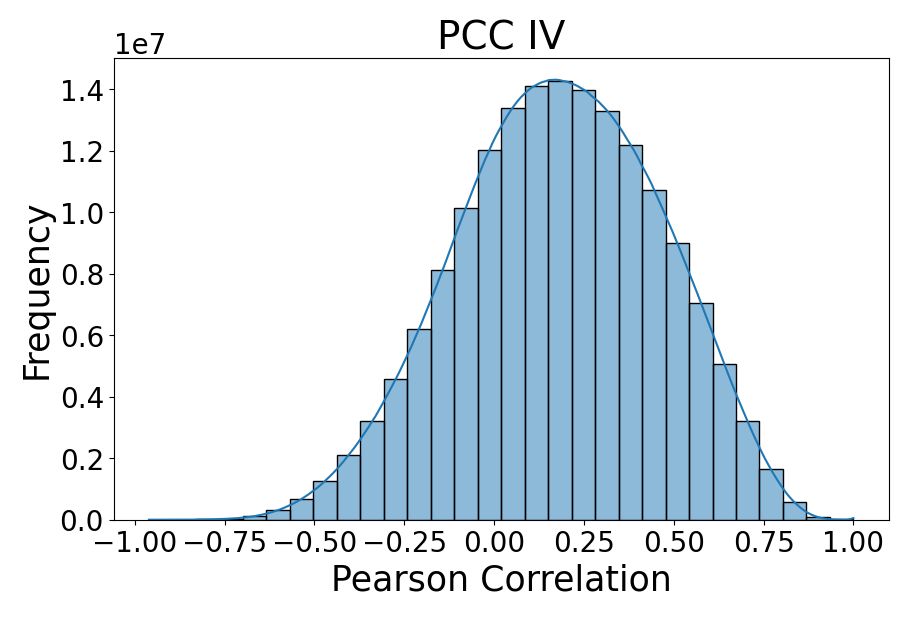

In [11]:
# Melt the DataFrame to long format
df_melted = pcc_IV.melt()

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_melted['value'], bins=30, kde=True)
plt.title('PCC IV')
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')

# Save the plot to a file
plt.savefig('./figures/pcc_IV.svg')
plt.show()